# 📓 Notebook 01 – Data Preprocessing
## Lettuce Fresh Weight Prediction | ANN + PSO

**Mode: Local (VS Code)**

Pipeline:
1. Load gambar `S001–S100` + label dari `measurements_raw.csv`
2. Validasi gambar
3. HSV Segmentation (background putih → isolasi hijau)
4. Morphological Cleaning
5. Augmentasi data → 200 gambar
6. Simpan konfigurasi

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, glob, pickle
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'axes.labelcolor': 'white', 'xtick.color': 'white',
    'ytick.color': 'white', 'text.color': 'white',
    'axes.edgecolor': '#0f3460', 'grid.color': '#0f3460',
})

print(f'✅ OpenCV  : {cv2.__version__}')
print(f'✅ NumPy   : {np.__version__}')
print(f'✅ Pandas  : {pd.__version__}')

✅ OpenCV  : 4.13.0
✅ NumPy   : 2.4.6
✅ Pandas  : 3.0.3


In [2]:
# ============================================================
#  PATH PROJECT – sesuaikan jika beda folder
# ============================================================
BASE_DIR  = r'D:/laragon/www/lettuce-weight-prediction'
IMAGE_DIR = f'{BASE_DIR}/data/raw/images'
CSV_PATH  = f'{BASE_DIR}/data/raw/measurements_raw.csv'
AUG_DIR   = f'{BASE_DIR}/data/augmented_images'

# HSV Range (background putih/terang)
LOWER_GREEN = np.array([20, 30, 30])
UPPER_GREEN = np.array([95, 255, 255])

# Buat folder output
for d in [AUG_DIR, f'{BASE_DIR}/output/models', f'{BASE_DIR}/output/plots']:
    os.makedirs(d, exist_ok=True)

print(f'📁 BASE_DIR   : {BASE_DIR}')
print(f'📷 IMAGE_DIR  : {IMAGE_DIR}')
print(f'📄 CSV_PATH   : {CSV_PATH}')
print(f'📁 AUG_DIR    : {AUG_DIR}')

📁 BASE_DIR   : D:/laragon/www/lettuce-weight-prediction
📷 IMAGE_DIR  : D:/laragon/www/lettuce-weight-prediction/data/raw/images
📄 CSV_PATH   : D:/laragon/www/lettuce-weight-prediction/data/raw/measurements_raw.csv
📁 AUG_DIR    : D:/laragon/www/lettuce-weight-prediction/data/augmented_images


## A. Load Dataset

In [3]:
# Load CSV label (separator semicolon)
df_csv = pd.read_csv(CSV_PATH, sep=';')
df_csv.columns = df_csv.columns.str.strip()

print(f'📊 Kolom CSV   : {df_csv.columns.tolist()}')
print(f'📊 Total baris : {len(df_csv)}')
print()
print('📈 Statistik Berat Segar Selada:')
print(df_csv['bobot_segar_gram'].describe().round(2))
print()
df_csv.head()

📊 Kolom CSV   : ['id_tanaman', 'foto', 'bobot_segar_gram']
📊 Total baris : 100

📈 Statistik Berat Segar Selada:
count    100.00
mean      31.97
std        5.90
min       18.00
25%       28.00
50%       31.00
75%       36.00
max       45.00
Name: bobot_segar_gram, dtype: float64



,id_tanaman,foto,bobot_segar_gram
0,S001,S001.jpeg,27
1,S002,S002.jpeg,37
2,S003,S003.jpeg,30
3,S004,S004.jpeg,41
4,S005,S005.jpeg,43


In [4]:
# Validasi: pastikan semua file gambar ada
valid_rows = []
missing    = []

for _, row in df_csv.iterrows():
    img_path = os.path.join(IMAGE_DIR, row['foto'])
    img_path = img_path.replace('\\', '/')
    if os.path.exists(img_path):
        img = cv2.imread(img_path)
        if img is not None:
            h, w = img.shape[:2]
            valid_rows.append({
                'id'         : row['id_tanaman'],
                'foto'       : row['foto'],
                'image_path' : img_path,
                'weight_gram': float(row['bobot_segar_gram']),
                'width'      : w,
                'height'     : h,
            })
        else:
            missing.append(row['foto'])
    else:
        missing.append(row['foto'])

df_valid = pd.DataFrame(valid_rows)

print(f'✅ Gambar valid  : {len(df_valid)}')
print(f'❌ Tidak ditemukan: {len(missing)}')
if missing:
    print('   File yang hilang:')
    for f in missing[:5]:
        print(f'   - {f}')

print(f'\n📊 Berat: min={df_valid["weight_gram"].min()}g | max={df_valid["weight_gram"].max()}g | rata2={df_valid["weight_gram"].mean():.2f}g')

✅ Gambar valid  : 100
❌ Tidak ditemukan: 0

📊 Berat: min=18.0g | max=45.0g | rata2=31.97g


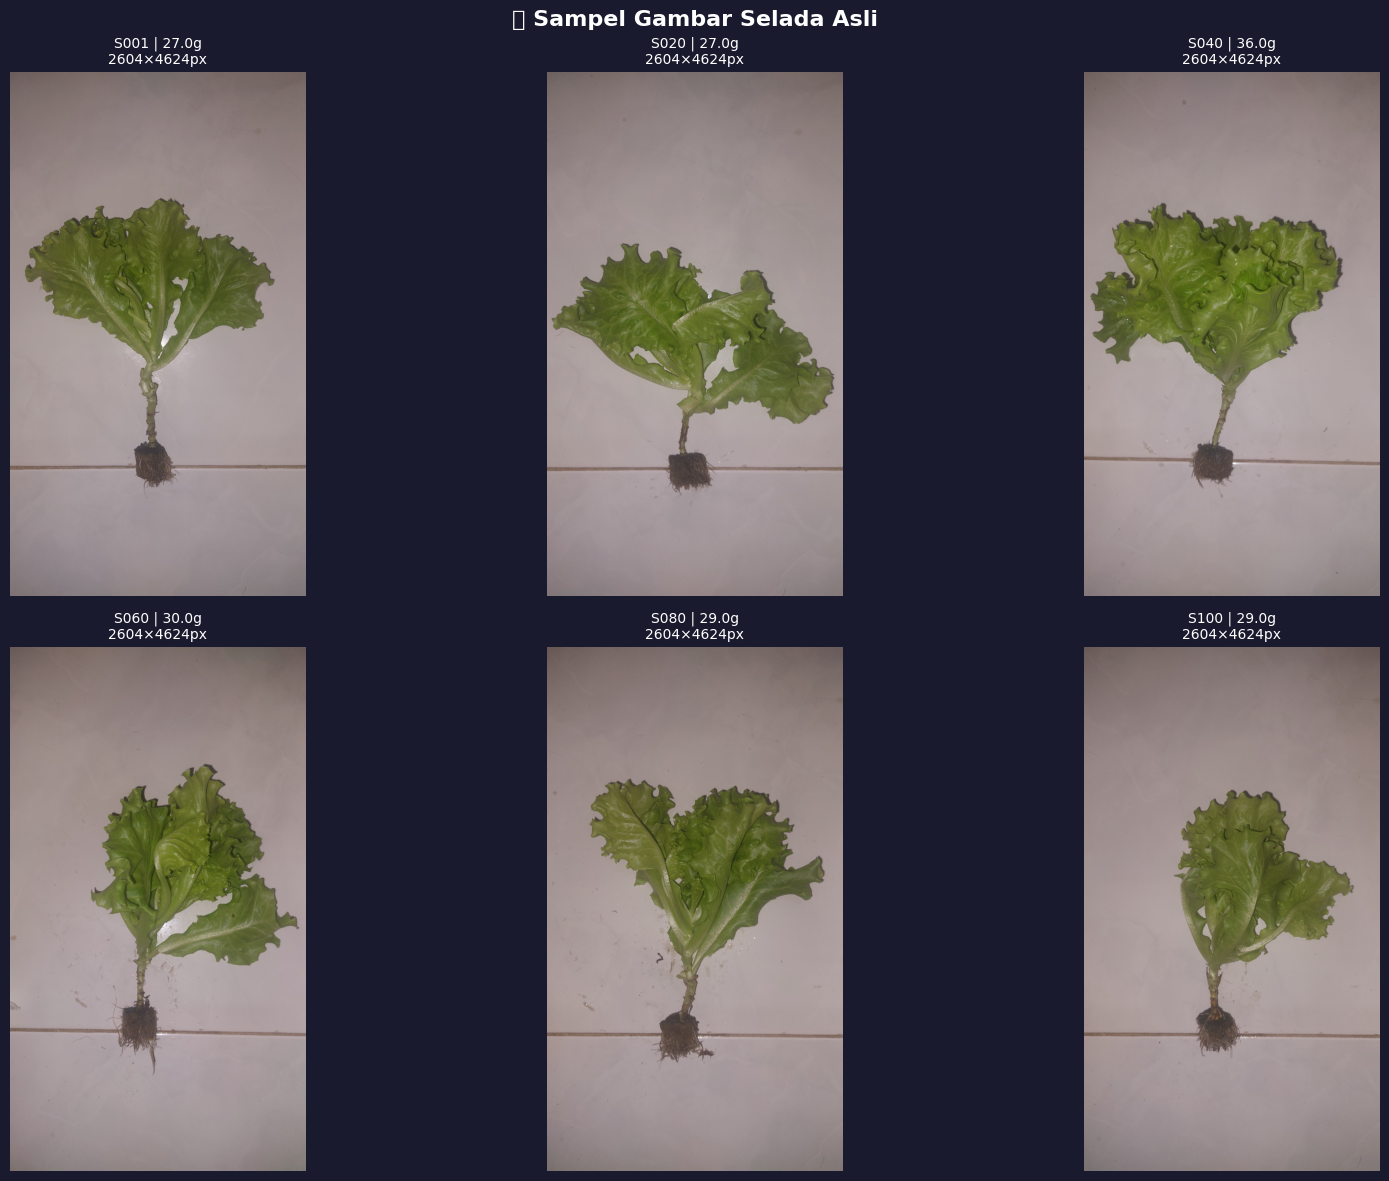

✅ Sampel gambar ditampilkan!


In [5]:
# Tampilkan 6 sampel gambar asli
n_show  = min(6, len(df_valid))
indices = np.linspace(0, len(df_valid)-1, n_show, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('📷 Sampel Gambar Selada Asli', fontsize=16, fontweight='bold', color='white')

for ax, idx in zip(axes.flatten(), indices):
    row = df_valid.iloc[idx]
    img = cv2.cvtColor(cv2.imread(row['image_path']), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f'{row["id"]} | {row["weight_gram"]}g\n{row["width"]}×{row["height"]}px', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/output/plots/sample_images.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('✅ Sampel gambar ditampilkan!')

## B. HSV Segmentation

> Gambar memiliki **background terang (putih/abu)** — threshold HSV disesuaikan.

In [6]:
def segment_lettuce(image_bgr, lower_green=None, upper_green=None):
    """
    Segmentasi selada: gabungan mask hijau (daun) + mask gelap (akar).
    Akar dideteksi via V<65 & S<80 (tanah gelap, bukan background terang).

    Returns:
        mask      : binary mask (uint8)
        segmented : gambar dengan area non-selada dihitamkan
    """
    lo = lower_green if lower_green is not None else np.array([20, 30, 30])
    hi = upper_green if upper_green is not None else np.array([95, 255, 255])

    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)

    # Mask 1: daun hijau
    mask_g = cv2.inRange(hsv, lo, hi)

    # Mask 2: akar gelap (V<65 & S<80 = tanah/akar, bukan background putih)
    mask_r = cv2.inRange(hsv, np.array([0, 0, 5]), np.array([180, 80, 75]))

    # Gabungkan daun + akar
    mask = cv2.bitwise_or(mask_g, mask_r)

    # Morphological operations
    k_open  = np.ones((3, 3), np.uint8)
    k_close = np.ones((7, 7), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  k_open,  iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k_close, iterations=3)

    # Ambil blob terbesar (tubuh utama selada + akar)
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if cnts:
        clean = np.zeros_like(mask)
        # Ambil semua blob signifikan (daun + akar), bukan hanya terbesar
        max_area = cv2.contourArea(max(cnts, key=cv2.contourArea))
        for cnt in cnts:
            if cv2.contourArea(cnt) > max(200, max_area * 0.02):
                cv2.drawContours(clean, [cnt], -1, 255, cv2.FILLED)
        mask = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, k_close, iterations=5)

    segmented = cv2.bitwise_and(image_bgr, image_bgr, mask=mask)
    return mask, segmented


print('✅ Fungsi segmentasi berhasil dibuat (dengan root detection)!')
print(f'   Daun HSV : {LOWER_GREEN.tolist()} → {UPPER_GREEN.tolist()}')
print(f'   Akar HSV : [0,0,5] → [180,80,75]  (V<75, S<80 = gelap)')


✅ Fungsi segmentasi berhasil dibuat (dengan root detection)!
   Daun HSV : [20, 30, 30] → [95, 255, 255]
   Akar HSV : [0,0,5] → [180,80,75]  (V<75, S<80 = gelap)


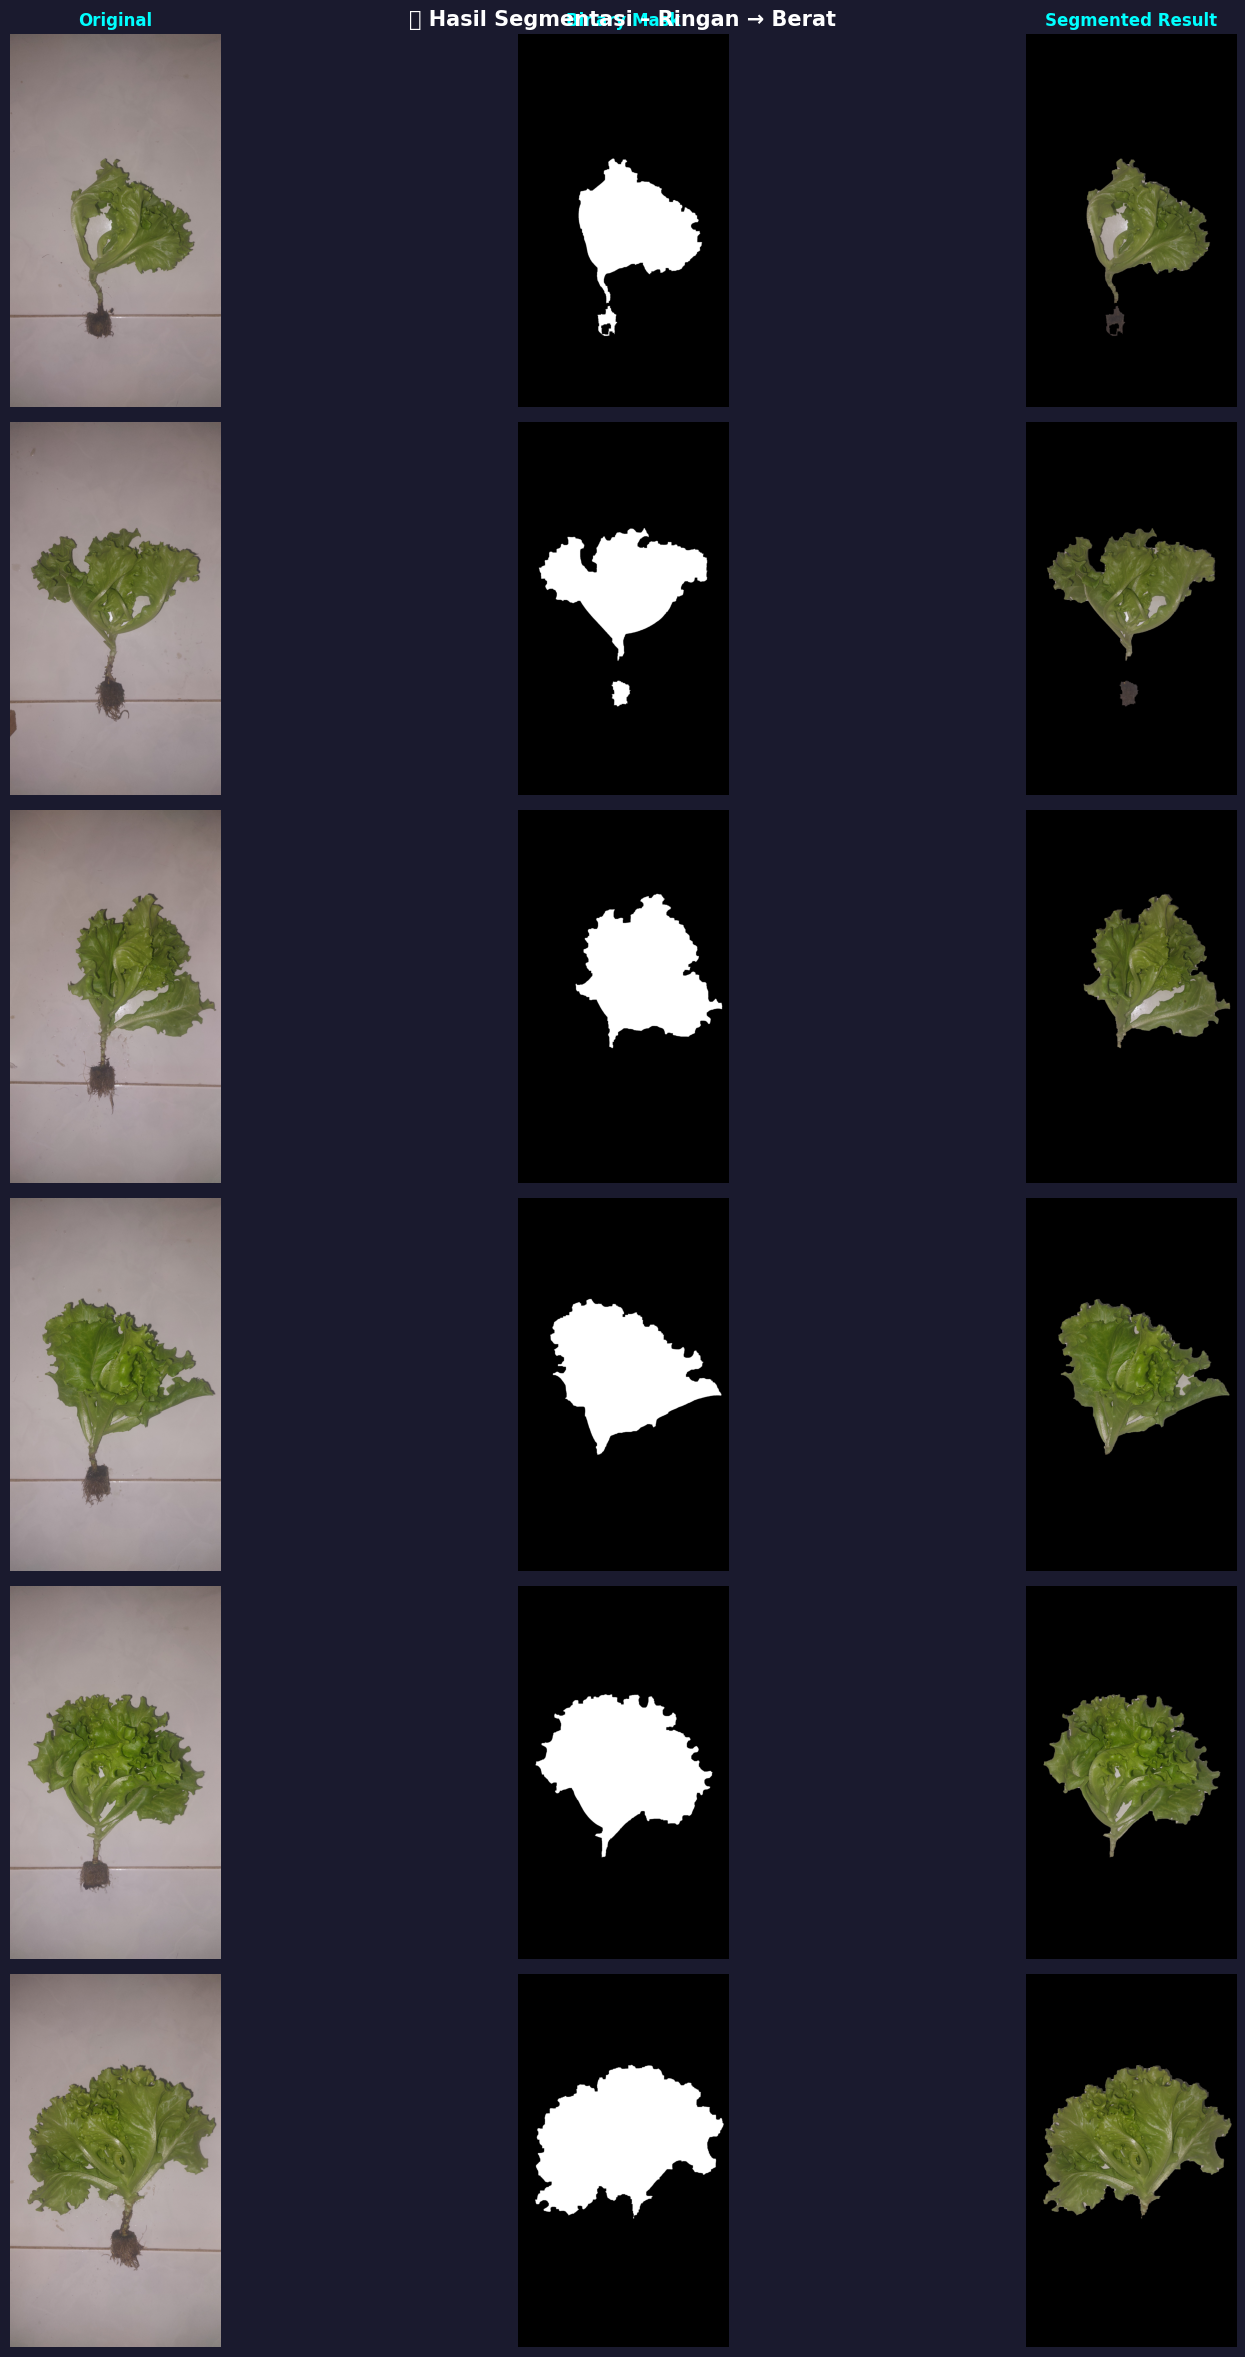

✅ Simpan → output/plots/segmentation_results.png


In [7]:
# Test segmentasi – tampilkan 6 gambar dari berat paling ringan ke terberat
sorted_df = df_valid.sort_values('weight_gram').reset_index(drop=True)
test_idx  = [0, 20, 40, 60, 80, 99]

fig, axes = plt.subplots(len(test_idx), 3, figsize=(18, len(test_idx) * 4))
fig.suptitle('🔬 Hasil Segmentasi – Ringan → Berat', fontsize=15, fontweight='bold', color='white')

# Header kolom
for ax, lbl in zip(axes[0], ['Original', 'Binary Mask', 'Segmented Result']):
    ax.set_title(lbl, fontsize=12, fontweight='bold', color='cyan')

for row_i, img_i in enumerate(test_idx):
    row      = sorted_df.iloc[img_i]
    img_bgr  = cv2.imread(row['image_path'])
    mask, seg = segment_lettuce(img_bgr, LOWER_GREEN, UPPER_GREEN)
    cov       = np.count_nonzero(mask) / mask.size * 100

    axes[row_i, 0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[row_i, 0].set_ylabel(f'{row["id"]}\n{row["weight_gram"]}g', fontsize=9, color='white')
    axes[row_i, 0].axis('off')

    axes[row_i, 1].imshow(mask, cmap='gray')
    axes[row_i, 1].set_xlabel(f'Coverage: {cov:.1f}%', fontsize=9, color='white')
    axes[row_i, 1].axis('off')

    axes[row_i, 2].imshow(cv2.cvtColor(seg, cv2.COLOR_BGR2RGB))
    axes[row_i, 2].axis('off')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/output/plots/segmentation_results.png', dpi=120, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('✅ Simpan → output/plots/segmentation_results.png')

---
## 🔍 Cek Root Detection
> Jalankan cell ini untuk verifikasi segmentasi akar sebelum lanjut.
> Kolom: **Original | Mask Hijau | Mask Akar | Gabungan | Result**

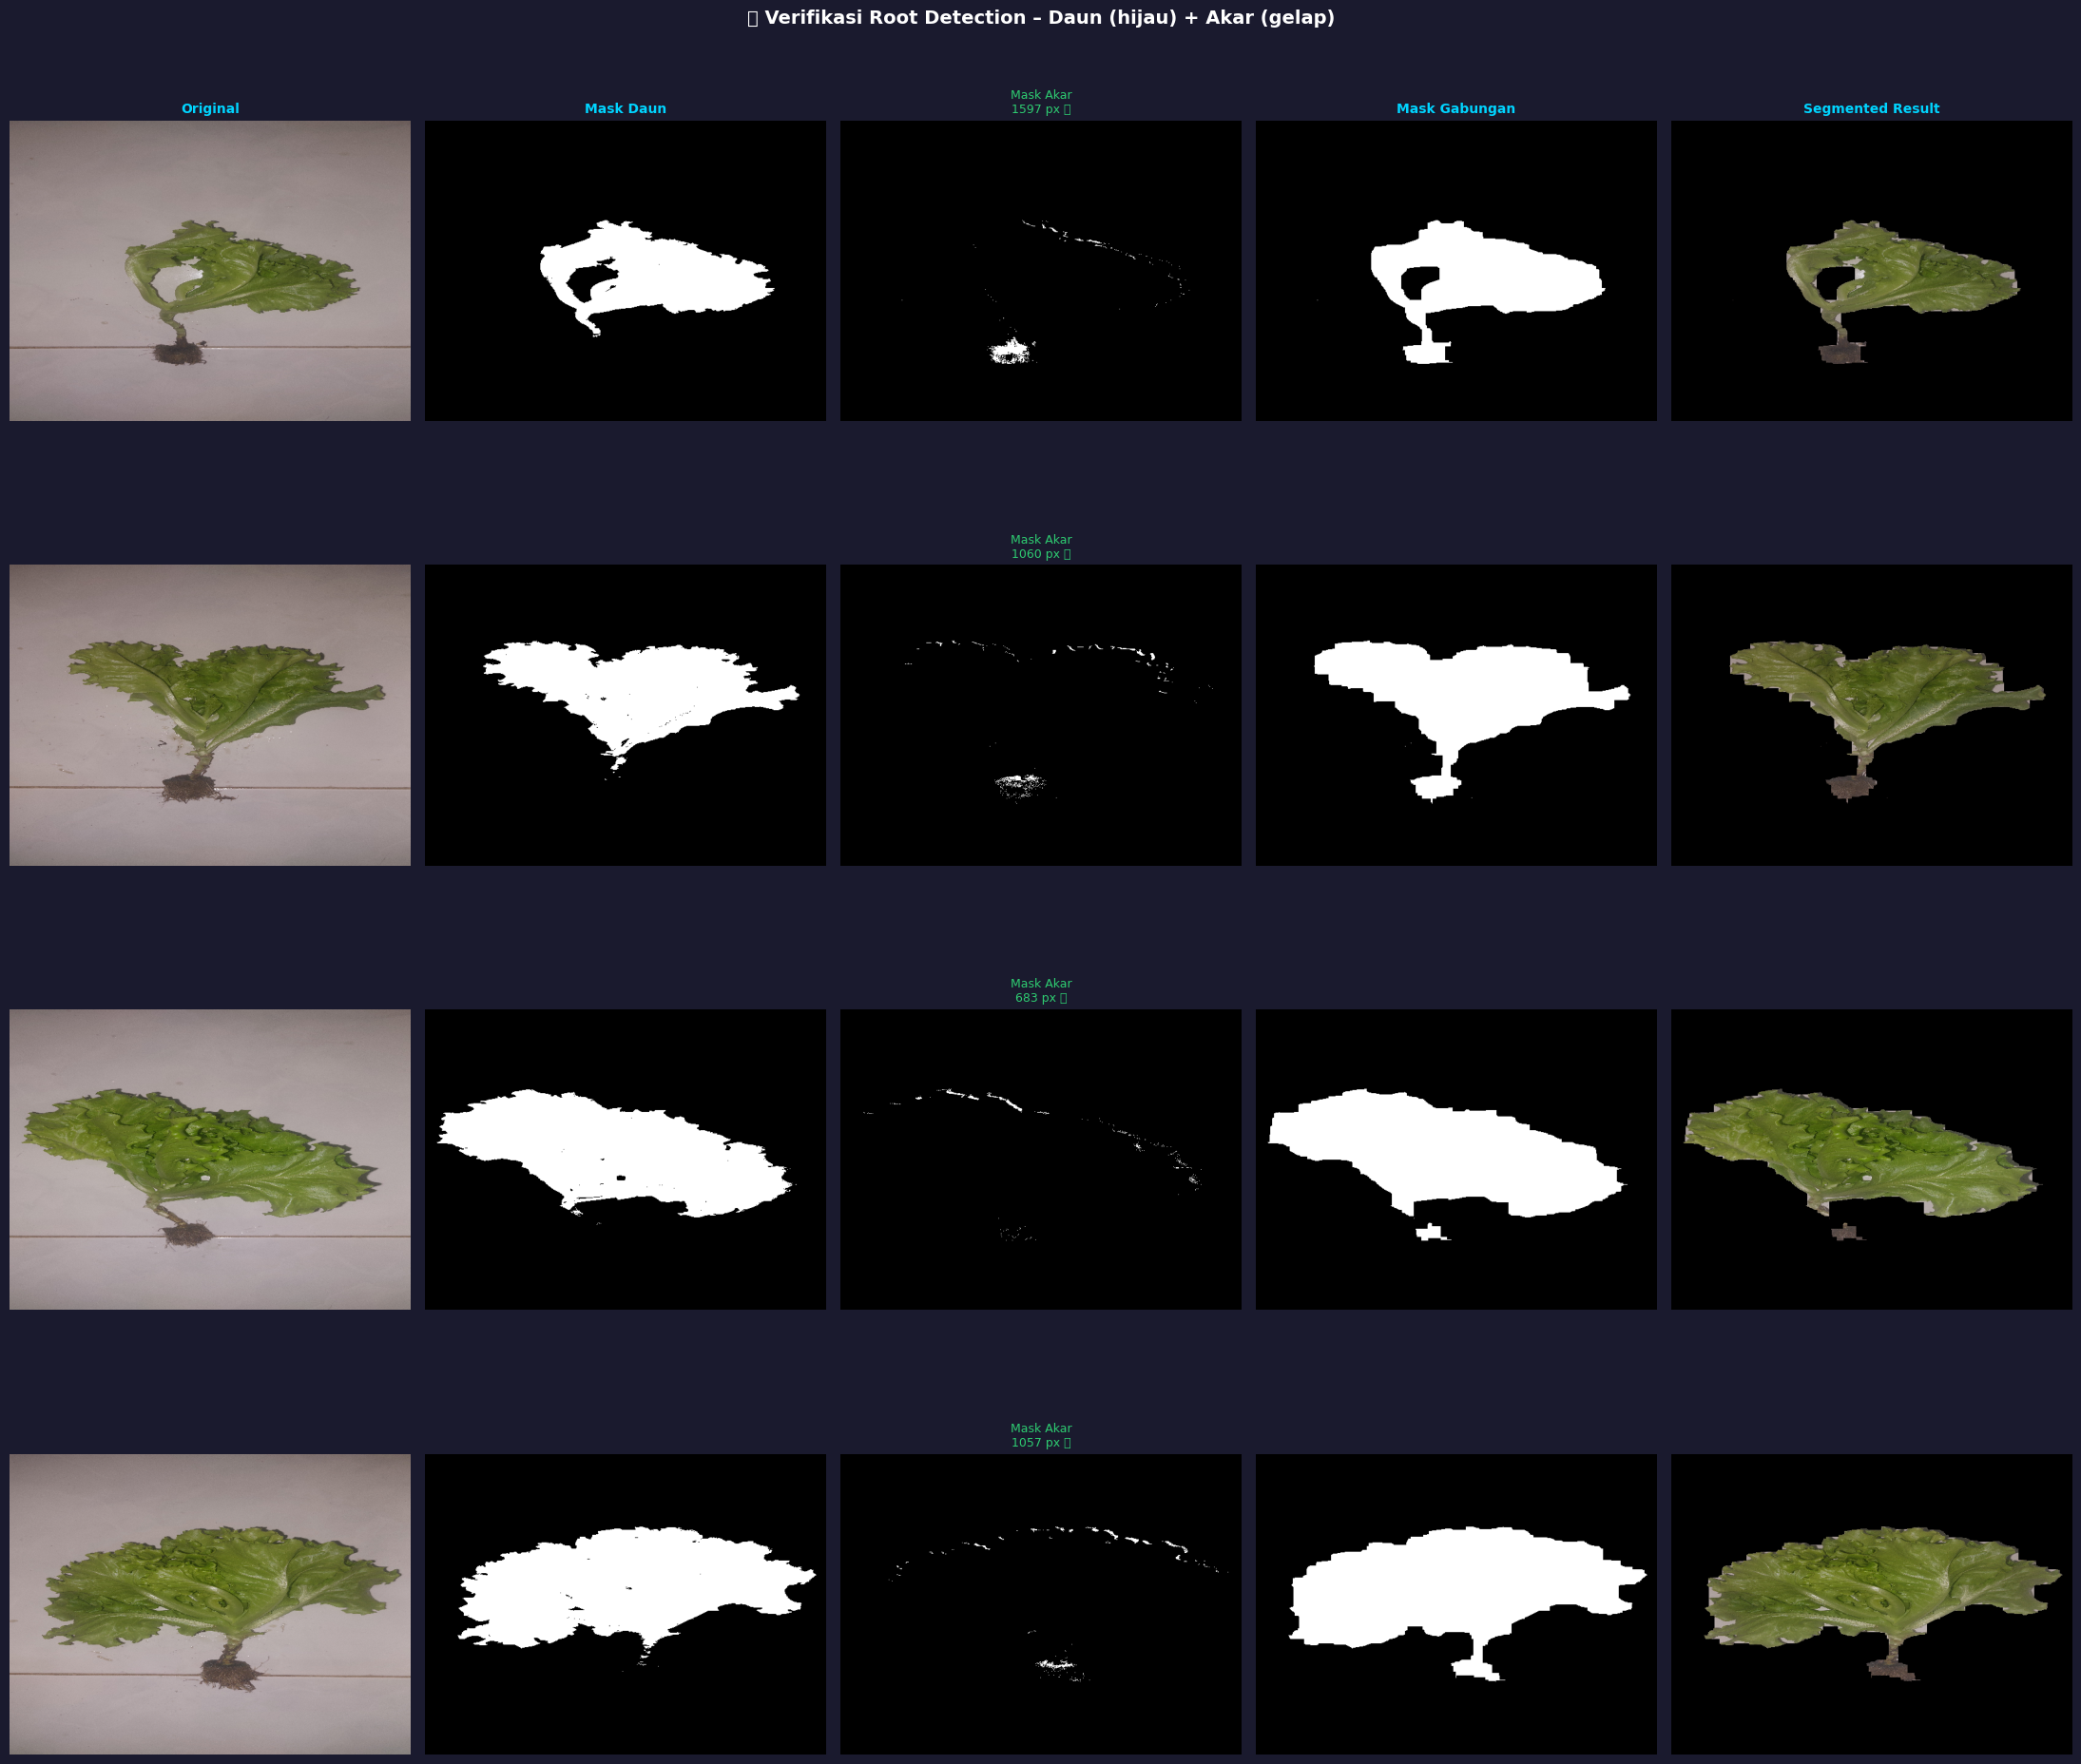


📊 Ringkasan Root Detection:
   ID         Berat    Px Daun    Px Akar          Status
   -------------------------------------------------------
   S014         18g      34086       1597    ✅ Terdeteksi
   S080         29g      46894       1060    ✅ Terdeteksi
   S023         35g      65371        683    ✅ Terdeteksi
   S067         45g      71258       1057    ✅ Terdeteksi


In [8]:
# ── CEK ROOT DETECTION ──────────────────────────────────────────────────
# Jalankan cell ini DULU sebelum lanjut ke augmentasi
# untuk memastikan akar terdeteksi dengan benar

import matplotlib.patches as mpatches

# Pilih 4 gambar: ringan, sedang-1, sedang-2, berat
sorted_all = df_valid.sort_values('weight_gram').reset_index(drop=True)
n = len(sorted_all)
idx_pick = [0, n//3, 2*n//3, n-1]
samples  = sorted_all.iloc[idx_pick]

fig, axes = plt.subplots(len(samples), 5, figsize=(22, 5*len(samples)))
fig.suptitle('🔍 Verifikasi Root Detection – Daun (hijau) + Akar (gelap)',
             fontsize=14, fontweight='bold', color='white')

col_titles = ['Original', 'Mask Daun', 'Mask Akar', 'Mask Gabungan', 'Segmented Result']
for ax, t in zip(axes[0], col_titles):
    ax.set_title(t, fontsize=10, fontweight='bold', color='#00D4FF')

for row, (_, srow) in enumerate(samples.iterrows()):
    img = cv2.imread(srow['image_path'])
    img = cv2.resize(img, (640, 480))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask terpisah
    mask_g = cv2.inRange(hsv, np.array([20, 30, 30]), np.array([95, 255, 255]))
    mask_r = cv2.inRange(hsv, np.array([0,  0,  5]),  np.array([180, 80, 75]))

    # Gabungan + morphology
    k = np.ones((7,7), np.uint8)
    mask_comb = cv2.bitwise_or(mask_g, mask_r)
    mask_comb = cv2.morphologyEx(mask_comb, cv2.MORPH_CLOSE, k, iterations=3)

    segmented = cv2.bitwise_and(img, img, mask=mask_comb)

    imgs = [
        cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
        mask_g,
        mask_r,
        mask_comb,
        cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB),
    ]
    cmaps = [None, 'gray', 'gray', 'gray', None]

    root_px   = np.count_nonzero(mask_r)
    green_px  = np.count_nonzero(mask_g)
    total_px  = 640 * 480

    for col, (im, cm) in enumerate(zip(imgs, cmaps)):
        axes[row, col].imshow(im, cmap=cm)
        axes[row, col].axis('off')

    axes[row, 0].set_ylabel(
        f"{srow['id']}  {srow['weight_gram']:.0f}g",
        fontsize=9, color='white', rotation=0, labelpad=80, va='center'
    )
    root_status = '✅' if root_px > 100 else '❌ Tidak terdeteksi'
    axes[row, 2].set_title(
        f'Mask Akar\n{root_px} px {root_status}',
        fontsize=9, color='#2ECC71' if root_px > 100 else '#E74C3C'
    )

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/output/plots/root_detection_check.png',
            dpi=120, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print('\n📊 Ringkasan Root Detection:')
print(f'   {"ID":<8} {"Berat":>7} {"Px Daun":>10} {"Px Akar":>10} {"Status":>15}')
print('   ' + '-'*55)
for _, srow in samples.iterrows():
    im = cv2.resize(cv2.imread(srow['image_path']), (640,480))
    h  = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
    mg = cv2.inRange(h, np.array([20,30,30]), np.array([95,255,255]))
    mr = cv2.inRange(h, np.array([0,0,5]),    np.array([180,80,75]))
    pg = np.count_nonzero(mg); pr = np.count_nonzero(mr)
    status = '✅ Terdeteksi' if pr > 100 else '❌ GAGAL'
    print(f'   {srow["id"]:<8} {srow["weight_gram"]:>6.0f}g {pg:>10} {pr:>10} {status:>15}')


## C. Augmentasi Data (100 → 200 Gambar)

In [9]:
def augment_image(img_bgr, aug_type):
    """Augmentasi gambar dengan berbagai transformasi."""
    h, w = img_bgr.shape[:2]
    if aug_type == 'rotate':
        angle = np.random.choice([-30, -15, 15, 30])
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
        return cv2.warpAffine(img_bgr, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    elif aug_type == 'flip_h':
        return cv2.flip(img_bgr, 1)
    elif aug_type == 'flip_v':
        return cv2.flip(img_bgr, 0)
    elif aug_type == 'brightness':
        return cv2.convertScaleAbs(img_bgr, alpha=np.random.uniform(0.7, 1.3), beta=0)
    elif aug_type == 'contrast':
        return cv2.convertScaleAbs(img_bgr, alpha=np.random.uniform(0.85, 1.15),
                                    beta=np.random.uniform(-20, 20))
    return img_bgr.copy()


TARGET_TOTAL = 200
AUG_TYPES    = ['rotate', 'flip_h', 'flip_v', 'brightness', 'contrast']
aug_records  = []
aug_count    = 0

print(f'🔄 Augmentasi ({len(df_valid)} → {TARGET_TOTAL} gambar)...')

# Salin gambar asli
for _, row in tqdm(df_valid.iterrows(), total=len(df_valid), desc='Copy originals'):
    img  = cv2.imread(row['image_path'])
    dest = os.path.join(AUG_DIR, row['foto'])
    cv2.imwrite(dest, img)
    aug_records.append({'image_path': dest.replace('\\','/'),
                         'weight_gram': row['weight_gram'],
                         'id': row['id'], 'is_augmented': False})

# Tambah augmented hingga TARGET_TOTAL
np.random.seed(42)
while len(aug_records) < TARGET_TOTAL:
    row      = df_valid.iloc[aug_count % len(df_valid)]
    aug_type = AUG_TYPES[aug_count % len(AUG_TYPES)]
    img      = cv2.imread(row['image_path'])
    aug_img  = augment_image(img, aug_type)
    new_name = f"{row['id']}_aug{aug_count:04d}_{aug_type}.jpg"
    dest     = os.path.join(AUG_DIR, new_name).replace('\\', '/')
    cv2.imwrite(dest, aug_img)
    aug_records.append({'image_path': dest, 'weight_gram': row['weight_gram'],
                         'id': row['id'], 'is_augmented': True})
    aug_count += 1

df_augmented = pd.DataFrame(aug_records)
print(f'\n✅ Augmentasi selesai!')
print(f'   Gambar asli       : {df_valid.shape[0]}')
print(f'   Gambar augmented  : {df_augmented["is_augmented"].sum()}')
print(f'   Total             : {len(df_augmented)}')

🔄 Augmentasi (100 → 200 gambar)...


Copy originals: 100%|██████████| 100/100 [00:11<00:00,  8.35it/s]



✅ Augmentasi selesai!
   Gambar asli       : 100
   Gambar augmented  : 100
   Total             : 200


## D. Simpan Konfigurasi

In [10]:
config = {
    'BASE_DIR'        : BASE_DIR,
    'IMAGE_DIR'       : IMAGE_DIR,
    'CSV_PATH'        : CSV_PATH,
    'AUG_DIR'         : AUG_DIR,
    'lower_green'     : LOWER_GREEN.tolist(),
    'upper_green'     : UPPER_GREEN.tolist(),
    'df_valid_dict'   : df_valid.to_dict('records'),
    'df_aug_dict'     : df_augmented.to_dict('records'),
    'all_image_paths' : df_valid['image_path'].tolist(),
    'aug_image_paths' : df_augmented['image_path'].tolist(),
    'use_augmented'   : True,
}

os.makedirs(f'{BASE_DIR}/data', exist_ok=True)
with open(f'{BASE_DIR}/data/preprocessing_config.pkl', 'wb') as f:
    pickle.dump(config, f)

print('=' * 55)
print('✅ NOTEBOOK 01 SELESAI!')
print('=' * 55)
print(f'  Gambar valid      : {len(df_valid)}')
print(f'  Total (augmented) : {len(df_augmented)}')
print(f'  HSV Range         : {LOWER_GREEN} – {UPPER_GREEN}')
print()
print('📌 Lanjut → 02_Feature_Extraction.ipynb')

✅ NOTEBOOK 01 SELESAI!
  Gambar valid      : 100
  Total (augmented) : 200
  HSV Range         : [20 30 30] – [ 95 255 255]

📌 Lanjut → 02_Feature_Extraction.ipynb
